# Reasoning-token sweep across frontier LLMs

Fire several frontier **reasoning-capable** models at a slice of GSM8K and sweep each
model's *thinking-effort* knob across the levels it actually supports. The deliverable
is the **reasoning / thinking token count** each model spends per effort level, alongside
accuracy, total output tokens, and latency.

## Providers

- **Fireworks** (OpenAI-compatible endpoint) — GLM-5.2, GLM-5.1, Kimi K2.6,
  DeepSeek V4 Pro, MiniMax M2.7, MiniMax M3, Qwen3.7 Plus. Reasoning is
  controlled via `reasoning_effort`
  (`"none"` / `"low"` / `"medium"` / `"high"` / `"max"`, model-dependent) and the
  thinking trace is returned in `reasoning_content`. Reasoning token count comes from
  `usage.completion_tokens_details.reasoning_tokens` (with a tiktoken fallback on
  `reasoning_content` if the field is absent).
- **OpenAI** (native SDK) — a GPT-5-series reasoning model. `reasoning_effort`
  (`"none"` / `"low"` / `"medium"` / `"high"`); reasoning tokens come from
  `usage.completion_tokens_details.reasoning_tokens`. Reasoning text is hidden.
- **Anthropic** (native SDK) — Claude Opus 4.8 with **adaptive** thinking
  (`thinking.type=enabled` + `budget_tokens` is rejected — Opus 4.8 is adaptive-only).
  Effort is swept via `output_config.effort` (`"low"` / `"medium"` / `"high"` /
  `"xhigh"` / `"max"`). Thinking text is returned via `display: "summarized"` (Opus 4.8
  defaults to `omitted`). Thinking token count comes from
  `usage.output_tokens_details.thinking_tokens` — an exact vendor count.

Each model declares its own valid effort ladder, so levels a model rejects (or collapses
into a neighbor) are handled per-model rather than via one fixed global ladder.

**Prereqs:** `FIREWORKS_API_KEY`, `OPENAI_API_KEY`, `ANTHROPIC_API_KEY` in
`training/.env` or your shell. Missing keys skip that provider's models (the rest still
run). Run the install cell once if imports fail.


In [1]:
# Run once if imports fail (uses the notebook kernel's Python).
import sys
!{sys.executable} -m pip install -q openai anthropic tiktoken matplotlib python-dotenv

## Config

Edit the model registry to add/remove models or adjust effort ladders. Each entry:
- `provider` — `"fireworks"` | `"openai"` | `"anthropic"`
- `model` — the provider's model id
- `efforts` — the list of effort levels to sweep (strings for all providers:
  fireworks/openai use `reasoning_effort`, anthropic uses `output_config.effort`).
  The special string `"default"` means *omit the reasoning param entirely*
  (use the model's default behavior).
- `param` — which knob: `"reasoning_effort"` or `"effort"` (informational)

Model ids and supported levels evolve over time — if a level 400s, it shows up as an
error row in the results (and is skipped in the sweep summary) rather than killing the run.


In [2]:
# --- edit these ---
MAX_ROWS = 8              # GSM8K rows per (model, effort) cell. Smoke=8; bump for a real sweep.
CONCURRENCY = 4           # simultaneous in-flight requests (shared across all models)
REQUEST_TIMEOUT = 1800    # seconds, per request
MAX_TOKENS = None        # fireworks + openai output cap (openai uses max_completion_tokens)
DATASET_URL = "https://raw.githubusercontent.com/eval-protocol/python-sdk/main/development/gsm8k_sample.jsonl"

MODELS = [
    {
        "label": "GLM-5.2 (Fireworks)",
        "provider": "fireworks",
        "model": "accounts/fireworks/models/glm-5p2",
        # Two thinking tiers: high + max. 'none' disables.
        "efforts": ["none", "high", "max"],
        "param": "reasoning_effort",
    },
    {
        "label": "GLM-5.1 (Fireworks)",
        "provider": "fireworks",
        "model": "accounts/fireworks/models/glm-5p1",
        # Binary on/off. 'default' = model default (on); 'none' disables.
        "efforts": ["none", "default"],
        "param": "reasoning_effort",
    },
    {
        "label": "Kimi K2.6 (Fireworks)",
        "provider": "fireworks",
        # K2 Thinking was discontinued 2026-05-25; migrate to kimi-k2p6.
        # K2.6 thinking is on/off via reasoning_effort (true/"high"/"none").
        "model": "accounts/fireworks/models/kimi-k2p6",
        "efforts": ["none", "default", "high"],
        "param": "reasoning_effort",
    },
    {
        "label": "DeepSeek V4 Pro (Fireworks)",
        "provider": "fireworks",
        # No bare 'deepseek-v4'; serverless ids are deepseek-v4-pro / -flash.
        # Accepts none/low/medium/high/xhigh/max; xhigh promoted to max.
        "model": "accounts/fireworks/models/deepseek-v4-pro",
        "efforts": ["none", "low", "medium", "high", "max"],
        "param": "reasoning_effort",
    },
    {
        "label": "MiniMax M2.7 (Fireworks)",
        "provider": "fireworks",
        # minimax-m2 is on-demand only (not serverless); serverless successor is m2p7.
        # Always-on; rejects 'none'. Accepts only low/medium/high.
        "model": "accounts/fireworks/models/minimax-m2p7",
        "efforts": ["low", "medium", "high"],
        "param": "reasoning_effort",
    },
    {
        "label": "Qwen3.7 Plus (Fireworks)",
        "provider": "fireworks",
        # Qwen3 text models were retired from Fireworks serverless; qwen3p7-plus
        # is the current serverless Qwen. 'none' disables thinking, else on.
        # reasoning_tokens isn't populated in usage, so the tiktoken fallback on
        # reasoning_content estimates it.
        "model": "accounts/fireworks/models/qwen3p7-plus",
        "efforts": ["none", "low", "medium", "high"],
        "param": "reasoning_effort",
    },
    {
        "label": "MiniMax M3 (Fireworks)",
        "provider": "fireworks",
        # Accepts none/low/medium/high; 'none' disables. reasoning_tokens not in
        # usage, so reasoning_content is tiktoken-estimated by the fallback.
        "model": "accounts/fireworks/models/minimax-m3",
        "efforts": ["none", "low", "medium", "high"],
        "param": "reasoning_effort",
    },
    {
        "label": "GPT-5.1 (OpenAI)",
        "provider": "openai",
        "model": "gpt-5.1",
        "efforts": ["none", "low", "medium", "high"],
        "param": "reasoning_effort",
    },
    {
        "label": "Claude Opus 4.8 (Anthropic)",
        "provider": "anthropic",
        "model": "claude-opus-4-8",
        # Opus 4.8 is adaptive-only: rejects thinking.type=enabled + budget_tokens.
        # Effort = output_config.effort: low/medium/high/xhigh/max ('none' rejected).
        "efforts": ["low", "medium", "high", "xhigh", "max"],
        "param": "effort",
    },
]

def effort_label(eff) -> str:
    if isinstance(eff, int):
        return f"{eff // 1000}k" if eff >= 1000 else str(eff)
    return str(eff)


In [3]:
import asyncio
import os
import re
import time
import urllib.request
import json as _json
from pathlib import Path

from dotenv import load_dotenv

training_dir = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if p.name == "training" and (p / "pyproject.toml").exists()),
    Path("../../").resolve(),
)
load_dotenv(training_dir / ".env")

HAVE = {
    "fireworks": bool(os.getenv("FIREWORKS_API_KEY")),
    "openai": bool(os.getenv("OPENAI_API_KEY")),
    "anthropic": bool(os.getenv("ANTHROPIC_API_KEY")),
}
missing = [p for p, ok in HAVE.items() if not ok]
if missing:
    print(f"Warning: missing API keys for {missing} — those providers will be skipped. "
          f"Set them in {training_dir / '.env'} or your shell.")


In [4]:
def load_rows(url: str, max_rows: int) -> list[dict]:
    raw = urllib.request.urlopen(url).read().decode().splitlines()
    return [_json.loads(line) for line in raw if line.strip()][:max_rows]

rows = load_rows(DATASET_URL, MAX_ROWS)
print(f"Loaded {len(rows)} GSM8K rows from {DATASET_URL}")

def split_messages(row: dict):
    system = next((m["content"] for m in row["messages"] if m["role"] == "system"), None)
    user = next((m["content"] for m in row["messages"] if m["role"] == "user"), "")
    return system, user


Loaded 8 GSM8K rows from https://raw.githubusercontent.com/eval-protocol/python-sdk/main/development/gsm8k_sample.jsonl


In [5]:
_ANSWER_TAG_RE = re.compile(r"<answer>\s*(.*?)\s*</answer>", re.IGNORECASE | re.DOTALL)
_DIGITS_RE = re.compile(r"(-?\d+(?:\.\d+)?)")

def extract_answer(text: str) -> str | None:
    if not text:
        return None
    m = _ANSWER_TAG_RE.search(text)
    chunk = m.group(1) if m else text
    digits = _DIGITS_RE.findall(chunk.replace(",", ""))
    return digits[-1] if digits else None

def grade(text: str, gt_raw: str) -> float:
    pred = extract_answer(text)
    gt = extract_answer(str(gt_raw))
    if pred is None or gt is None:
        return 0.0
    return 1.0 if pred == gt else 0.0


In [6]:
import tiktoken
_enc = tiktoken.get_encoding("cl100k_base")

def estimate_tokens(text: str) -> int:
    """Rough token count via cl100k_base — a cross-model estimate, not exact per vendor."""
    if not text:
        return 0
    return len(_enc.encode(text))


## Per-provider call functions

Each returns a dict with `text`, `reasoning_text`, `reasoning_tokens`, `completion_tokens`,
`prompt_tokens`, and `requested_effort`. Reasoning tokens are taken from the provider's
usage object when available (Fireworks/OpenAI `completion_tokens_details.reasoning_tokens`;
Anthropic `output_tokens_details.thinking_tokens`) and fall back to a tiktoken estimate
of the returned thinking text otherwise.


In [7]:
from openai import AsyncOpenAI
from anthropic import AsyncAnthropic

fw_client = AsyncOpenAI(
    base_url="https://api.fireworks.ai/inference/v1",
    api_key=os.environ.get("FIREWORKS_API_KEY", ""),
    timeout=REQUEST_TIMEOUT,
) if HAVE["fireworks"] else None

oai_client = AsyncOpenAI(
    api_key=os.environ.get("OPENAI_API_KEY", ""),
    timeout=REQUEST_TIMEOUT,
) if HAVE["openai"] else None

anthropic_client = AsyncAnthropic(
    api_key=os.environ.get("ANTHROPIC_API_KEY", ""),
    timeout=REQUEST_TIMEOUT,
) if HAVE["anthropic"] else None


async def call_fireworks(model: str, eff, system: str, user: str) -> dict:
    msgs = []
    if system:
        msgs.append({"role": "system", "content": system})
    msgs.append({"role": "user", "content": user})
    kwargs = {"model": model, "messages": msgs, "max_tokens": MAX_TOKENS, "temperature": 0.0}
    if eff != "default":
        kwargs["reasoning_effort"] = eff
    t0 = time.perf_counter()
    resp = await fw_client.chat.completions.create(**kwargs)
    dt = time.perf_counter() - t0
    msg = resp.choices[0].message
    text = msg.content or ""
    reasoning_text = getattr(msg, "reasoning_content", None) or ""
    u = resp.usage
    details = getattr(u, "completion_tokens_details", None)
    rtok = getattr(details, "reasoning_tokens", None)
    if not rtok:
        # Fallback: estimate from the returned reasoning trace.
        rtok = estimate_tokens(reasoning_text)
    return {
        "text": text,
        "reasoning_text": reasoning_text,
        "reasoning_tokens": rtok or 0,
        "completion_tokens": u.completion_tokens or 0,
        "prompt_tokens": u.prompt_tokens or 0,
        "latency": dt,
    }


async def call_openai(model: str, eff, system: str, user: str) -> dict:
    msgs = []
    if system:
        msgs.append({"role": "system", "content": system})
    msgs.append({"role": "user", "content": user})
    kwargs = {"model": model, "messages": msgs, "max_completion_tokens": MAX_TOKENS}
    if eff != "default":
        kwargs["reasoning_effort"] = eff
    t0 = time.perf_counter()
    resp = await oai_client.chat.completions.create(**kwargs)
    dt = time.perf_counter() - t0
    msg = resp.choices[0].message
    text = msg.content or ""
    u = resp.usage
    details = getattr(u, "completion_tokens_details", None)
    rtok = getattr(details, "reasoning_tokens", None) or 0
    return {
        "text": text,
        "reasoning_text": "",  # OpenAI hides the reasoning trace.
        "reasoning_tokens": rtok,
        "completion_tokens": u.completion_tokens or 0,
        "prompt_tokens": u.prompt_tokens or 0,
        "latency": dt,
    }


async def call_anthropic(model: str, eff, system: str, user: str) -> dict:
    # Opus 4.8 is adaptive-only: rejects thinking.type=enabled + budget_tokens (400).
    # Use thinking.type=adaptive + output_config.effort. display=summarized so the
    # thinking block returns text (Opus 4.8 defaults to "omitted"). Thinking token
    # count comes from usage.output_tokens_details.thinking_tokens (exact, no estimate).
    # Anthropic requires max_tokens to be a concrete int (unlike Fireworks/OpenAI
    # which accept None for unbounded). Fall back to a sane cap when MAX_TOKENS is
    # None. Keep it <=16000: the SDK forces streaming for non-streaming requests
    # whose max_tokens implies a >10min op, and this call path is non-streaming.
    anthropic_max_tokens = MAX_TOKENS if isinstance(MAX_TOKENS, int) else 16000
    kwargs = {
        "model": model,
        "max_tokens": anthropic_max_tokens,
        "thinking": {"type": "adaptive", "display": "summarized"},
        "output_config": {"effort": str(eff)},
        "messages": [{"role": "user", "content": user}],
    }
    if system:
        kwargs["system"] = system
    t0 = time.perf_counter()
    resp = await anthropic_client.messages.create(**kwargs)
    dt = time.perf_counter() - t0
    thinking_parts, text_parts = [], []
    for b in resp.content:
        if getattr(b, "type", None) == "thinking":
            thinking_parts.append(getattr(b, "thinking", "") or "")
        elif getattr(b, "type", None) == "text":
            text_parts.append(getattr(b, "text", "") or "")
    thinking_text = "".join(thinking_parts)
    text = "".join(text_parts)
    details = getattr(resp.usage, "output_tokens_details", None)
    rtok = getattr(details, "thinking_tokens", None) or 0
    return {
        "text": text,
        "reasoning_text": thinking_text,
        "reasoning_tokens": rtok,  # exact vendor count from output_tokens_details
        "completion_tokens": resp.usage.output_tokens,
        "prompt_tokens": resp.usage.input_tokens,
        "latency": dt,
    }


PROVIDER_FN = {
    "fireworks": call_fireworks,
    "openai": call_openai,
    "anthropic": call_anthropic,
}


## Run the sweep

For every (model, effort, GSM8K row) triple, call the provider and record token usage +
latency+accuracy. A single shared semaphore bounds concurrency. Per-request errors become
rows with `error` set (and zeros elsewhere) so a bad model/level doesn't abort the sweep.


In [8]:
def skip_model(m: dict) -> bool:
    return not HAVE.get(m["provider"], False)

async def preflight(models: list[dict], rows: list[dict]) -> list[dict]:
    """One cheap call per model (first effort, first row) before the full sweep.

    Catches bad model ids / unsupported params in seconds instead of after a
    30-minute run. Returns the subset of models that answered successfully;
    prints a one-line pass/fail per model with the error for failures.
    """
    system, user = split_messages(rows[0])
    good: list[dict] = []
    print("Preflight (1 call per model):")
    for m in models:
        if skip_model(m):
            print(f"  SKIP  {m['label']} (no API key for {m['provider']})")
            continue
        eff = m["efforts"][0]
        try:
            await PROVIDER_FN[m["provider"]](m["model"], eff, system, user)
            print(f"  OK    {m['label']}")
            good.append(m)
        except Exception as e:  # noqa: BLE001
            print(f"  FAIL  {m['label']} @ {effort_label(eff)} -> {type(e).__name__}: {str(e)[:140]}")
    dropped = [m["label"] for m in models if not skip_model(m) and m not in good]
    if dropped:
        print(f"\nDropping {len(dropped)} model(s) that failed preflight: {dropped}")
    return good


async def run_sweep(models: list[dict], rows: list[dict]) -> list[dict]:
    sem = asyncio.Semaphore(CONCURRENCY)
    records: list[dict] = []

    async def one(m: dict, eff, row, idx):
        if skip_model(m):
            return
        system, user = split_messages(row)
        label = effort_label(eff)
        rec = {
            "model": m["label"], "provider": m["provider"], "model_id": m["model"],
            "effort": label, "effort_raw": eff, "row": idx,
            "reasoning_tokens": 0, "completion_tokens": 0, "prompt_tokens": 0,
            "total_tokens": 0, "latency": 0.0, "score": 0.0,
            "error": None, "estimated": False,
        }
        async with sem:
            try:
                fn = PROVIDER_FN[m["provider"]]
                out = await fn(m["model"], eff, system, user)
                rec.update(
                    reasoning_tokens=out["reasoning_tokens"],
                    completion_tokens=out["completion_tokens"],
                    prompt_tokens=out["prompt_tokens"],
                    total_tokens=(out["prompt_tokens"] + out["completion_tokens"]),
                    latency=out["latency"],
                    score=grade(out["text"], row["ground_truth"]),
                    estimated=out.get("estimated", False),
                )
            except Exception as e:  # noqa: BLE001
                rec["error"] = f"{type(e).__name__}: {str(e)[:160]}"
        records.append(rec)

    tasks = []
    for m in models:
        if skip_model(m):
            print(f"  skipping {m['label']} (no API key for {m['provider']})")
            continue
        for eff in m["efforts"]:
            for idx, row in enumerate(rows):
                tasks.append(one(m, eff, row, idx))
    await asyncio.gather(*tasks)
    return records

# Preflight first so a bad model id / unsupported param fails in seconds, not
# after the full sweep. Set RUN_PREFLIGHT=False to skip and sweep every model.
RUN_PREFLIGHT = True
sweep_models = await preflight(MODELS, rows) if RUN_PREFLIGHT else MODELS
print(f"\nSweeping {len(sweep_models)} models x efforts x {MAX_ROWS} rows @ concurrency={CONCURRENCY} ...")
records = await run_sweep(sweep_models, rows)
ok = [r for r in records if not r["error"]]
errs = [r for r in records if r["error"]]
print(f"Done: {len(ok)} ok, {len(errs)} errored across {len(records)} calls.")
if errs:
    from collections import Counter
    by_provider = Counter(r["provider"] for r in errs)
    print("Errors by provider:", dict(by_provider))
    by_model = Counter(r["model"] + " @ " + r["effort"] for r in errs)
    print("Errors by model@effort (all):")
    for k, v in by_model.most_common():
        print(f"  {v:>3}  {k}")
    # One representative error per provider, so a 404 on Fireworks doesn't
    # hide a different failure mode on OpenAI/Anthropic.
    by_prov_err = {}
    for r in errs:
        by_prov_err.setdefault(r["provider"], r["error"])
    print("\nRepresentative error per provider:")
    for prov, msg in by_prov_err.items():
        print(f"  [{prov}] {msg}")


Preflight (1 call per model):
  OK    GLM-5.2 (Fireworks)
  OK    GLM-5.1 (Fireworks)
  OK    Kimi K2.6 (Fireworks)
  OK    DeepSeek V4 Pro (Fireworks)
  OK    MiniMax M2.7 (Fireworks)
  OK    Qwen3.7 Plus (Fireworks)
  OK    MiniMax M3 (Fireworks)
  OK    GPT-5.1 (OpenAI)
  OK    Claude Opus 4.8 (Anthropic)

Sweeping 9 models x efforts x 8 rows @ concurrency=4 ...
Done: 264 ok, 0 errored across 264 calls.


## Results

Long-format per-call table, then a per-(model, effort) summary.


In [9]:
import pandas as pd

df = pd.DataFrame(records)
# Keep errored rows visible but mark them. Use isna() rather than truthiness:
# under pandas 3.0 a column mixing None + strings becomes `str` dtype where the
# missing entries are <NA>, which is truthy in `if e` — that would mislabel every
# row as "error" whenever any call failed, silently zeroing the summary/charts.
df["status"] = df["error"].isna().map({True: "ok", False: "error"})

cols = ["model", "provider", "effort", "row", "reasoning_tokens", "completion_tokens",
        "total_tokens", "latency", "score", "status"]
display_cols = [c for c in cols if c in df.columns]
df[display_cols].head(20)


,model,provider,effort,row,reasoning_tokens,completion_tokens,total_tokens,latency,score,status
0,GLM-5.2 (Fireworks),fireworks,none,0,226,254,575,1.603281,1.0,ok
1,GLM-5.2 (Fireworks),fireworks,none,4,0,13,322,0.616312,1.0,ok
2,GLM-5.2 (Fireworks),fireworks,none,2,0,319,660,3.157616,1.0,ok
3,GLM-5.2 (Fireworks),fireworks,none,3,270,292,626,4.138986,1.0,ok
4,GLM-5.2 (Fireworks),fireworks,none,1,381,493,805,5.368565,1.0,ok
5,GLM-5.2 (Fireworks),fireworks,none,6,0,146,485,3.102650,1.0,ok
6,GLM-5.2 (Fireworks),fireworks,none,5,422,668,1014,5.674209,1.0,ok
7,GLM-5.2 (Fireworks),fireworks,high,0,197,302,629,3.016114,1.0,ok
8,GLM-5.2 (Fireworks),fireworks,high,1,214,336,654,2.599423,1.0,ok
9,GLM-5.2 (Fireworks),fireworks,none,7,0,265,654,7.091728,1.0,ok


In [10]:
def summarize(d: pd.DataFrame) -> pd.DataFrame:
    g = d[d["status"] == "ok"].groupby(["model", "provider", "effort"], sort=False)
    summ = g.agg(
        n=("row", "count"),
        mean_reasoning_tokens=("reasoning_tokens", "mean"),
        mean_completion_tokens=("completion_tokens", "mean"),
        mean_total_tokens=("total_tokens", "mean"),
        mean_prompt_tokens=("prompt_tokens", "mean"),
        accuracy=("score", "mean"),
        mean_latency_s=("latency", "mean"),
    ).reset_index()
    # Count errored per (model,effort) so the summary flags unreliable cells.
    err = d[d["status"] == "error"].groupby(["model", "effort"]).size().rename("errors").reset_index()
    summ = summ.merge(err, on=["model", "effort"], how="left")
    summ["errors"] = summ["errors"].fillna(0).astype(int)
    summ["accuracy"] = (summ["accuracy"] * 100).round(1)
    for c in ["mean_reasoning_tokens", "mean_completion_tokens", "mean_total_tokens", "mean_prompt_tokens"]:
        summ[c] = summ[c].round(0).astype(int)
    summ["mean_latency_s"] = summ["mean_latency_s"].round(1)
    return summ

summary = summarize(df)
summary


,model,provider,effort,n,mean_reasoning_tokens,mean_completion_tokens,mean_total_tokens,mean_prompt_tokens,accuracy,mean_latency_s,errors
0,GLM-5.2 (Fireworks),fireworks,none,8,162,306,643,336,100.0,3.8,0
1,GLM-5.2 (Fireworks),fireworks,high,8,241,506,849,342,100.0,5.1,0
2,GLM-5.2 (Fireworks),fireworks,max,8,349,716,1058,342,87.5,7.6,0
3,GLM-5.1 (Fireworks),fireworks,none,8,0,434,764,329,100.0,5.8,0
4,GLM-5.1 (Fireworks),fireworks,default,8,359,578,907,329,100.0,9.1,0
5,Kimi K2.6 (Fireworks),fireworks,none,8,264,283,615,332,100.0,2.6,0
6,Kimi K2.6 (Fireworks),fireworks,default,8,60,561,892,331,100.0,5.0,0
7,Kimi K2.6 (Fireworks),fireworks,high,8,56,511,843,331,100.0,4.6,0
8,DeepSeek V4 Pro (Fireworks),fireworks,none,8,0,196,520,325,100.0,3.2,0
9,DeepSeek V4 Pro (Fireworks),fireworks,low,8,336,359,683,325,100.0,5.6,0


## Charts

One subplot per model showing **mean reasoning tokens by effort level** (the main
deliverable), with accuracy annotated on each bar. All reasoning-token counts are
exact vendor-reported values (Fireworks/OpenAI `reasoning_tokens`, Anthropic
`thinking_tokens`).


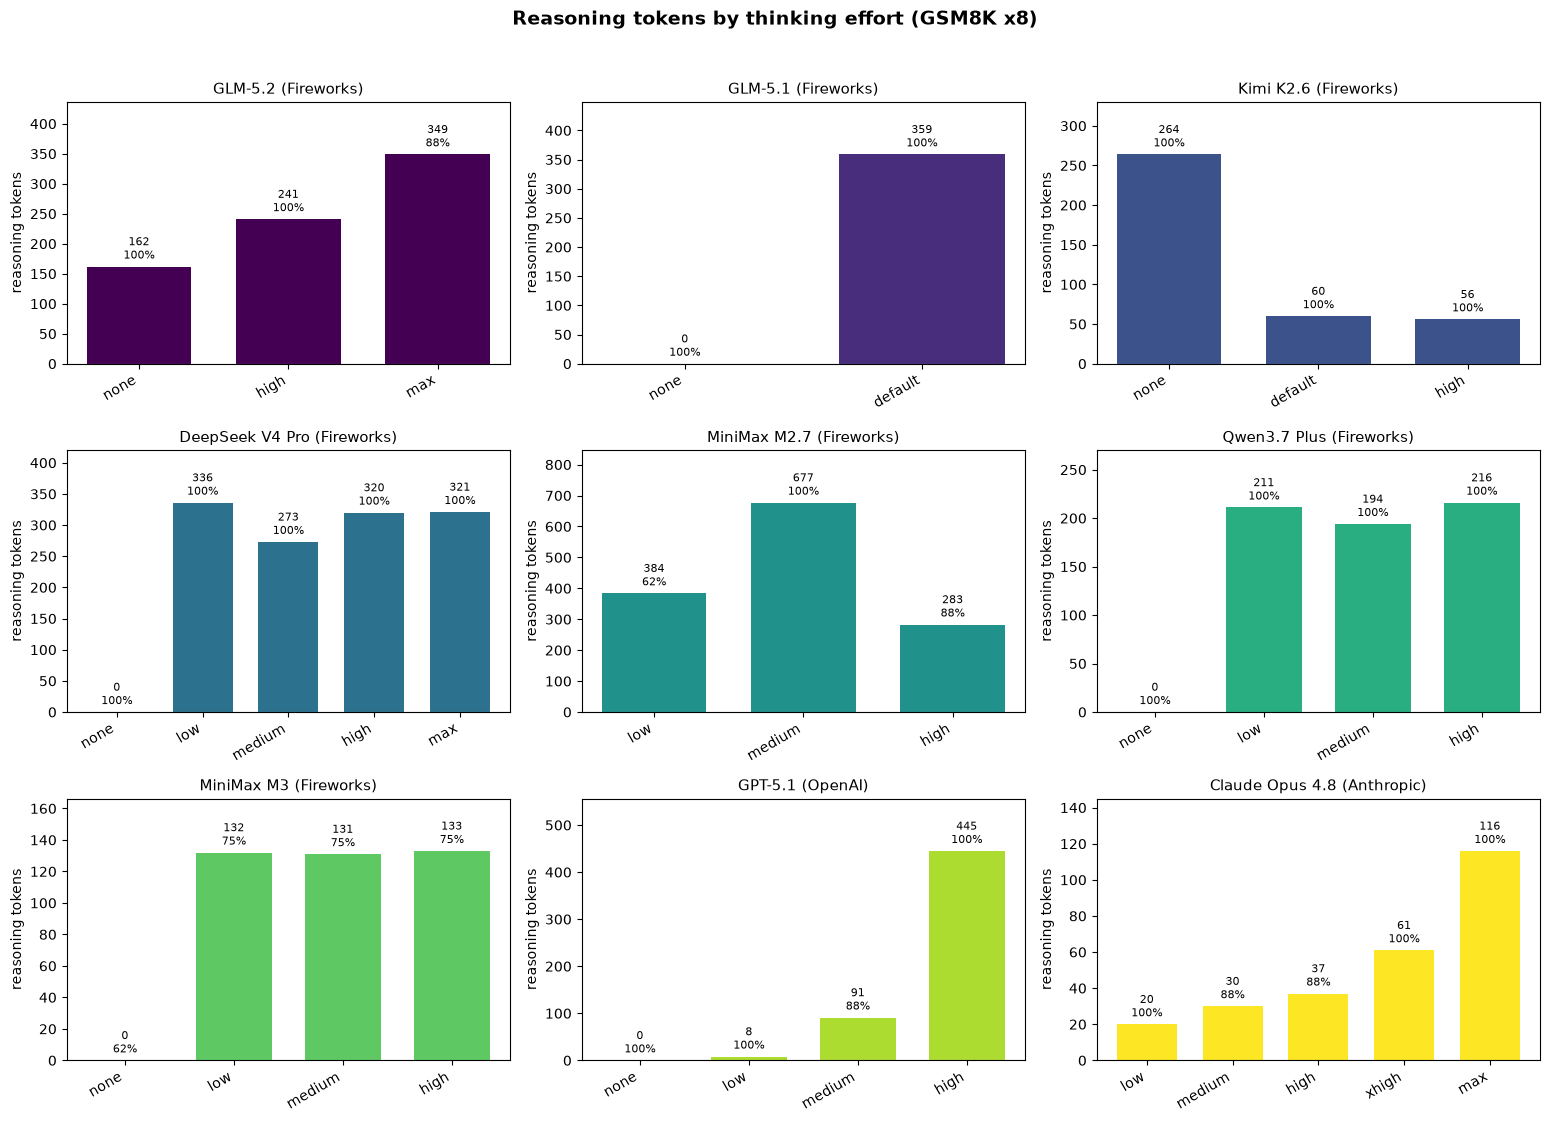

Saved reasoning_token_sweep.png


In [11]:
import matplotlib.pyplot as plt
import math

# Preserve the registry order so subplots match MODELS.
model_order = [m["label"] for m in MODELS if not skip_model(m)]
effort_order = {m["label"]: [effort_label(e) for e in m["efforts"]] for m in MODELS}

ncols = 3
nrows = math.ceil(len(model_order) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 3.8 * nrows), squeeze=False)
palette = plt.cm.viridis

for i, label in enumerate(model_order):
    ax = axes[i // ncols][i % ncols]
    effs = effort_order[label]
    sub = summary[summary["model"] == label].set_index("effort").reindex(effs)
    vals = sub["mean_reasoning_tokens"].fillna(0).values
    accs = sub["accuracy"].fillna(0).values
    errs = sub["errors"].fillna(0).values
    x = range(len(effs))
    bars = ax.bar(x, vals, color=palette(i / max(1, len(model_order) - 1)), width=0.7)
    ax.set_xticks(list(x))
    ax.set_xticklabels(effs, rotation=30, ha="right")
    ax.set_title(label, fontsize=11)
    ax.set_ylabel("reasoning tokens")
    ax.set_ylim(0, max(vals.max() * 1.25, 1))
    for j, (b, v, a, e) in enumerate(zip(bars, vals, accs, errs)):
        tag = f"{int(v)}\n{a:.0f}%"
        if e:
            tag += f"\n{int(e)} err"
        ax.text(b.get_x() + b.get_width() / 2, v + vals.max() * 0.02, tag,
                ha="center", va="bottom", fontsize=8)
    # Baseline at 0 for 'none' effort.
    ax.axhline(0, color="0.7", lw=0.8)

# Hide unused subplots.
for j in range(len(model_order), nrows * ncols):
    axes[j // ncols][j % ncols].axis("off")

fig.suptitle(f"Reasoning tokens by thinking effort (GSM8K x{MAX_ROWS})", fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("reasoning_token_sweep.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved reasoning_token_sweep.png")


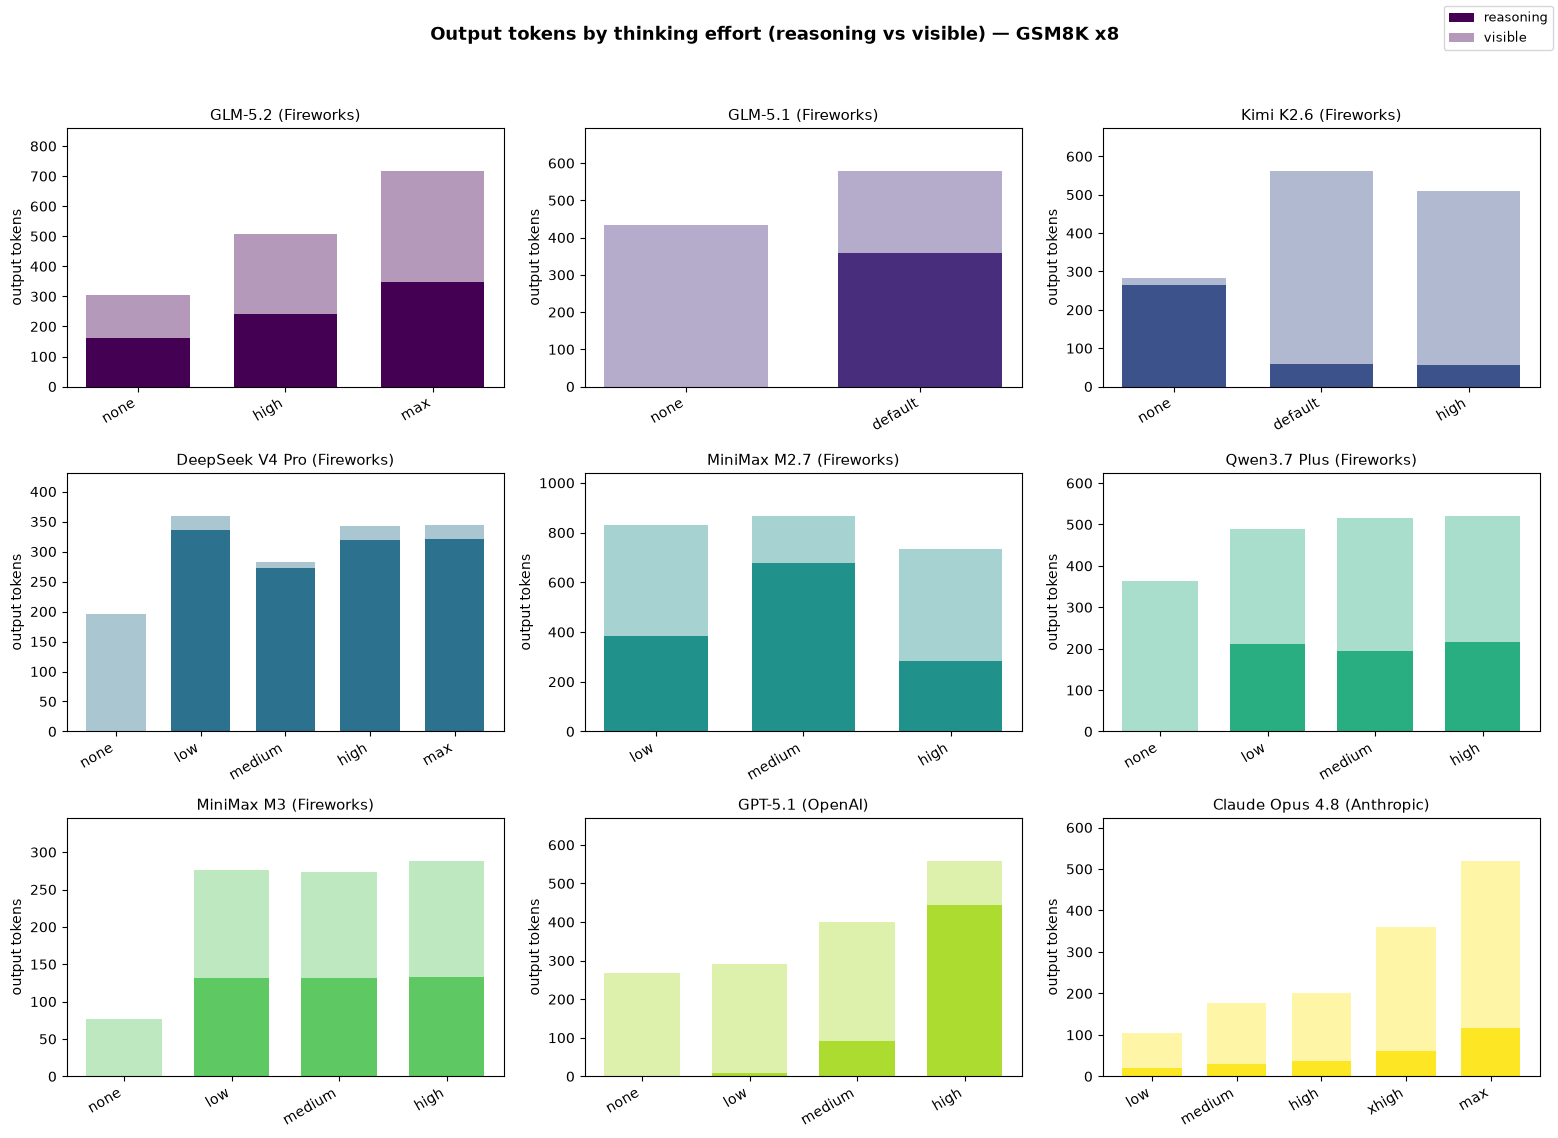

Saved reasoning_token_sweep_total.png


In [12]:
# Second view: total output tokens (reasoning + visible) per effort — i.e. cost shape.
fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 3.8 * nrows), squeeze=False)

for i, label in enumerate(model_order):
    ax = axes[i // ncols][i % ncols]
    effs = effort_order[label]
    sub = summary[summary["model"] == label].set_index("effort").reindex(effs)
    rt = sub["mean_reasoning_tokens"].fillna(0).values
    ct = sub["mean_completion_tokens"].fillna(0).values - rt  # visible (non-reasoning) share
    ct = [max(c, 0) for c in ct]
    x = range(len(effs))
    ax.bar(x, rt, color=palette(i / max(1, len(model_order) - 1)), width=0.7, label="reasoning")
    ax.bar(x, ct, bottom=rt, color=palette(i / max(1, len(model_order) - 1)), width=0.7, alpha=0.4, label="visible")
    ax.set_xticks(list(x))
    ax.set_xticklabels(effs, rotation=30, ha="right")
    ax.set_title(label, fontsize=11)
    ax.set_ylabel("output tokens")
    ax.set_ylim(0, max((rt + ct).max() * 1.2, 1))

for j in range(len(model_order), nrows * ncols):
    axes[j // ncols][j % ncols].axis("off")

handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", fontsize=9)
fig.suptitle(f"Output tokens by thinking effort (reasoning vs visible) — GSM8K x{MAX_ROWS}",
             fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("reasoning_token_sweep_total.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved reasoning_token_sweep_total.png")


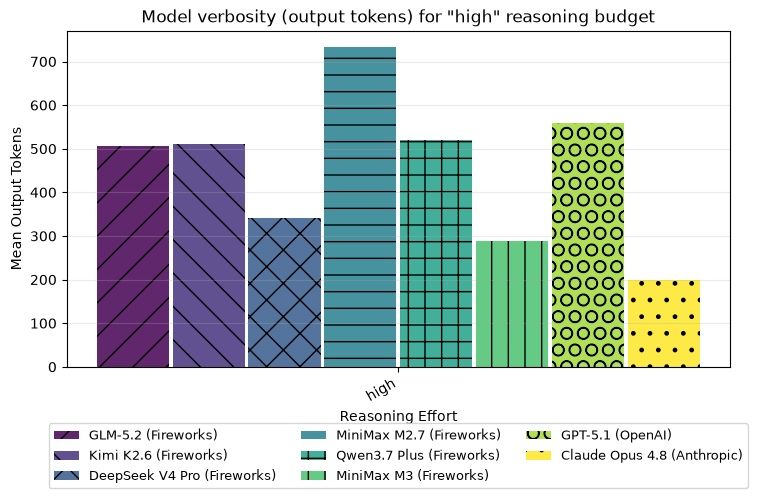

Saved reasoning_verbosity_across_models.png


In [17]:
# Plot model verbosity as a bar chart—mean output tokens per effort for each model (excluding GLM-5.1).

# Define reasoning budgets of interest -- pick values that occur for most models.
shared_efforts = ["high"]

# Identify which efforts are present per model (from summary)
available_efforts = set()
for effs in effort_order.values():
    available_efforts.update(effs)
effort_labels = [e for e in shared_efforts if e in available_efforts]

# Remove GLM-5.1 from model labels if present
model_labels = [m for m in model_order if "GLM-5.1" not in m]

verbosity_table = pd.DataFrame(index=model_labels, columns=effort_labels)
for label in model_labels:
    sub = summary[summary["model"] == label].set_index("effort")
    for eff in effort_labels:
        if eff in sub.index:
            row = sub.loc[eff]
            total_tokens = row.get("mean_completion_tokens", float("nan"))
            verbosity_table.loc[label, eff] = total_tokens
        else:
            verbosity_table.loc[label, eff] = float("nan")

# Bar chart: group by effort, side-by-side bars for each model within each effort.
import numpy as np

# Colorblind-friendly hatch patterns (repeat if models>patterns)
hatch_patterns = ['/', '\\', 'x', '-', '+', '|', 'O', '.', '*']
while len(hatch_patterns) < len(model_labels):
    hatch_patterns = hatch_patterns * 2  # repeat patterns if needed

fig, ax = plt.subplots(figsize=(7.5, 5))

x = np.arange(len(effort_labels))  # Effort indices
total_width = 0.8
bar_width = total_width / len(model_labels)
offsets = (np.arange(len(model_labels)) - (len(model_labels)-1)/2) * bar_width

bars = []
for i, label in enumerate(model_labels):
    vals = verbosity_table.loc[label].astype(float)
    bar = ax.bar(
        x + offsets[i],
        vals,
        width=bar_width * 0.95,
        label=label,
        color=palette(i / max(1, len(model_labels) - 1)),
        alpha=0.85,
        hatch=hatch_patterns[i % len(hatch_patterns)]
    )
    bars.append(bar[0])  # Just use first bar for the legend, since all in group look the same visually

ax.set_xticks(x)
ax.set_xticklabels(effort_labels, rotation=30, ha="right")
ax.set_xlabel("Reasoning Effort")
ax.set_ylabel("Mean Output Tokens")
ax.set_title("Model verbosity (output tokens) for \"high\" reasoning budget")
ax.grid(axis="y", alpha=0.25)

# Move legend below the plot
from matplotlib.legend import Legend
handles = [bar for bar in bars]
labels = model_labels

# Shrink y margin for legend room
plt.tight_layout(rect=[0, 0.11, 1, 1])
ax.legend(
    handles,
    labels,
    fontsize=9,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=min(3, len(model_labels)),
    frameon=True
)
plt.savefig("reasoning_verbosity_across_models.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved reasoning_verbosity_across_models.png")

## Notes / knobs

- **Token-count provenance.** Fireworks and OpenAI report `reasoning_tokens` in
  `usage.completion_tokens_details`; Anthropic reports `thinking_tokens` in
  `usage.output_tokens_details`. All three are exact vendor counts. (Fireworks additionally
  returns the full `reasoning_content` trace, used as a fallback when the usage field is
  absent.)
- **Per-model effort ladders.** Models accept different effort sets: GLM-5.2 is
  high/max, GLM-5.1 is binary on/off (`default` = on), Kimi K2.6 is on/off
  (`default` = on, `high` = on, `none` = off), DeepSeek V4 Pro accepts none→max,
  MiniMax M2.7 is always-on low/med/high (rejects `none`), GPT-5.1 is
  none/low/medium/high, Claude Opus 4.8 is adaptive-only with effort
  low/med/high/xhigh/max (rejects `none` and rejects the legacy `budget_tokens`
  contract). Edit the registry in the config cell to change the ladder or add models.
- **Errors.** A model×effort that 400s (e.g. wrong id, unsupported level) becomes error
  rows with zeros; the summary flags the count with `err` on the bar. Fix the model id /
  effort in config and rerun.
- **Cost / runtime.** Calls = models × efforts × rows. At `MAX_ROWS=8` with the default
  7-model registry that's ~260 calls; reasoning models can take 5–30s each, so expect
  ~10–25 min wall at `CONCURRENCY=5`. Bump `MAX_ROWS` for tighter numbers; raise
  `CONCURRENCY` if your rate limits allow.
- **Accuracy** is regex-graded (`<answer>N</answer>` → digits) and only directional at
  this sample size — the point of this notebook is the token-spend curve, not a
  benchmark verdict.
